# The Kirkwood Gaps

#### This tutorial demonstrates one of the most striking structures in the asteroid belt, and explains why you cannot see it on a map.

In 1866 Daniel Kirkwood noticed that the semi-major axes of the (then fewer than 100) known asteroids were not smoothly distributed: certain values were conspicuously avoided. These depleted bands — the [Kirkwood gaps](https://en.wikipedia.org/wiki/Kirkwood_gap) — occur at **mean-motion resonances** with Jupiter: semi-major axes where an asteroid would complete a simple whole-number ratio of orbits (3:1, 5:2, 7:3, 2:1, ...) for every orbit of Jupiter.

Here is the puzzle this notebook explores. A top-down map of the main belt containing a snapshot of well over a million asteroid positions shows **no gaps at all**: the belt looks like a smooth, dense annulus. Yet a histogram of the *same* orbits' semi-major axes shows the gaps razor-sharp. We build both views from the full MPCORB catalogue, then resolve the apparent paradox.

We will:
1. **Download and parse** the MPC's full orbit catalogue, [`MPCORB.DAT`](https://minorplanetcenter.net/iau/MPCORB.html) — roughly 1.5 million orbits
2. **Compute** every asteroid's position at the catalogue epoch with a vectorized two-body Kepler solver
3. **Map** the belt as an (x, y) position snapshot — and fail to find any gaps
4. **Histogram** the semi-major axes — and find the gaps immediately, lined up with Jupiter's resonances
5. **Resolve** the paradox by comparing the distributions of semi-major axis and heliocentric distance
6. **Redraw the map with every orbit circularized** — radius = semi-major axis — so the gaps finally appear as rings

This notebook reuses the download / parse / snapshot pipeline built (and explained step by step) in the [companion plotting tutorial](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_plotting/).

Further information:
- [Kirkwood gap (Wikipedia)](https://en.wikipedia.org/wiki/Kirkwood_gap)
- [Companion tutorial: Plotting Asteroid Orbits](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_plotting/)
- [Companion tutorial: From MPC Orbit to N-Body Simulation](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_to_rebound/)
- [MPC data page (bulk orbit files)](https://minorplanetcenter.net/data)

## Environment Setup

This notebook requires `rebound`, `matplotlib`, `numpy`, and `requests`. We recommend creating a dedicated conda environment and registering it as a Jupyter kernel so that all dependencies are isolated and reproducible.

Run the following commands once in a terminal before opening this notebook:

```bash
# Create and populate the environment
conda create -n orbit-tutorial python=3.11 -y
conda activate orbit-tutorial
pip install rebound mpc-orb astropy matplotlib numpy requests ipykernel

# Register the environment as a Jupyter kernel
python -m ipykernel install --user --name orbit-tutorial --display-name "Python (orbit-tutorial)"
```

If you do not already have a way of running Jupyter notebooks, also install Jupyter itself (`pip install jupyter`), then launch it from the directory containing this notebook with:

```bash
jupyter notebook
```

and open this file in the browser tab that appears. However you run the notebook, select **Kernel > Change Kernel > Python (orbit-tutorial)** before running the cells below.

If you already created the `orbit-tutorial` environment for the companion N-body tutorial, you can simply reuse it — no new packages are needed.


# Install and Import Packages

We need `requests` to download the catalogue, `numpy` and `matplotlib` for the computation and the figures, and `rebound` to load the planets from JPL Horizons for the map view.

In [1]:
import os
import gzip
import collections

import requests
import numpy as np
import matplotlib.pyplot as plt

import rebound

# Step 1: Download and Parse MPCORB

Our data source is the MPC's flagship orbit file, [`MPCORB.DAT`](https://minorplanetcenter.net/iau/MPCORB.html): roughly 1.5 million orbits in a fixed-width text format (about 90 MB gzipped), with the column layout documented on the [Minor Planet Orbit Format page](https://docs.minorplanetcenter.net/mpc-ops-docs/orbits/minor-planet-orbit-format/). Bulk orbit files are listed on the [MPC data page](https://minorplanetcenter.net/data).

The cell below is exactly the parsing pipeline from the [companion plotting tutorial](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_plotting/), where it is explained in detail: it streams the gzipped file, slices the six Keplerian elements and the packed epoch code out of each line, and counts how many orbits share each epoch.

**Download note:** the cell caches `MPCORB.DAT.gz` (about 90 MB) in the notebook's working directory and only downloads it if it is not already present. Delete the file to reclaim the space when you are done.

In [2]:
MPCORB_URL = "https://www.minorplanetcenter.net/iau/MPCORB/MPCORB.DAT.gz"
MPCORB_FILE = "MPCORB.DAT.gz"

if not os.path.exists(MPCORB_FILE):
    print(f"Downloading {MPCORB_URL} (about 90 MB; this may take a few minutes)")
    with requests.get(MPCORB_URL, stream=True, timeout=600) as r:
        r.raise_for_status()
        with open(MPCORB_FILE + ".part", "wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                f.write(chunk)
    os.rename(MPCORB_FILE + ".part", MPCORB_FILE)
    print("  done")
else:
    print(f"Using cached {MPCORB_FILE}")

# Fixed-width columns (1-indexed, from the orbit-format documentation):
# epoch 21-25 (packed), M 27-35, Peri 38-46, Node 49-57,
# i 60-68, e 71-79, a 93-103
rows = []
epoch_counts = collections.Counter()
with gzip.open(MPCORB_FILE, "rt") as f:
    in_header = True
    for line in f:
        if in_header:                      # header ends at a dashed line
            if line.startswith("----------"):
                in_header = False
            continue
        if len(line) < 104:                # skip blank section separators
            continue
        try:
            elems = (float(line[92:103]), float(line[70:79]),
                     float(line[59:68]), float(line[48:57]),
                     float(line[37:46]), float(line[26:35]))
        except ValueError:                 # rare rows with missing elements
            continue
        rows.append(elems + (line[20:25],))
        epoch_counts[line[20:25]] += 1

print(f"\nParsed {len(rows):,} orbits")
epoch_mode, n_mode = epoch_counts.most_common(1)[0]
print(f"Most common epoch: {epoch_mode!r} ({n_mode:,} orbits, "
      f"{100 * n_mode / len(rows):.1f} percent of the catalogue)")


Using cached MPCORB.DAT.gz



Parsed 1,562,078 orbits
Most common epoch: 'K2669' (1,552,194 orbits, 99.4 percent of the catalogue)


# Step 2: Select the Epoch and Compute Positions

Almost the whole catalogue shares one standard epoch, so we keep only the orbits at that modal epoch (with sanity cuts 0 < a < 6 AU and e < 1). Unlike the companion tutorial we keep the **full** set — roughly 1.5 million orbits — because the histograms to come need every object.

To place each asteroid at its position on the epoch we solve Kepler's equation `E - e sin E = M` for **all objects at once** with a few vectorized Newton iterations, then rotate the in-plane positions into the heliocentric ecliptic frame. This is the same solver used in the companion plotting tutorial, where it was cross-checked against REBOUND. This time we also keep the z-coordinate and record each object's instantaneous heliocentric distance `r` — it plays the starring role in Step 5.

In [3]:
# Orbits at the common epoch, inside Jupiter's neighbourhood -- the FULL set
el = np.array([r[:6] for r in rows if r[6] == epoch_mode])
el = el[(el[:, 0] > 0) & (el[:, 0] < 6.0) & (el[:, 1] < 1.0)]
print(f"{len(el):,} orbits with a < 6 AU at the common epoch")

# Vectorized two-body positions from Keplerian elements
a, e = el[:, 0], el[:, 1]
inc, node, peri, M = np.radians(el[:, 2:6]).T

E = M.copy()                             # solve Kepler: E - e sin E = M
for _ in range(30):                      # Newton iterations, all objects at once
    E -= (E - e * np.sin(E) - M) / (1 - e * np.cos(E))

xp = a * (np.cos(E) - e)                 # position in the orbital plane
yp = a * np.sqrt(1 - e**2) * np.sin(E)

cw, sw = np.cos(peri), np.sin(peri)      # rotate: R_z(node) R_x(inc) R_z(peri)
ci, si = np.cos(inc), np.sin(inc)
cO, sO = np.cos(node), np.sin(node)
x1, y1 = cw * xp - sw * yp, sw * xp + cw * yp
y2, z = ci * y1, si * y1
x = cO * x1 - sO * y2
y = sO * x1 + cO * y2

# Instantaneous heliocentric distance, for Step 5
r = np.sqrt(x**2 + y**2 + z**2)
print(f"Computed positions for all {len(x):,} objects")

1,544,495 orbits with a < 6 AU at the common epoch


Computed positions for all 1,544,495 objects


# Step 3: The Map View — a Snapshot of the Belt

First, the map. This reproduces the final figure of the companion plotting tutorial: one dot per asteroid at its position on the common epoch, with the Sun and the planets out to Jupiter loaded from JPL Horizons for context (the packed epoch code decodes to a calendar date for the Horizons query — see the [packed dates documentation](https://docs.minorplanetcenter.net/mpc-ops-docs/designations/packed-dates/)).

Drawing every object would just saturate the figure, so we subsample **for plotting only** — the histograms in Steps 4 and 5 always use the full population. As in the companion tutorial, the subsample is stratified: we keep *all* of the Hildas (a between 3.7 and 4.2 AU) and Jupiter Trojans (a between 5.0 and 5.4 AU), two small populations with spectacular structure, and subsample the vastly more numerous rest to 200,000 points. Since Step 2 already computed the positions, the masks are simply applied to the ready-made arrays.

NB: If loading the planets fails with an SSL-certificate `RuntimeError` from NASA Horizons, simply re-run the cell — the retry typically succeeds (see the note in the companion tutorial).

In [4]:
# Stratified subsample FOR PLOTTING ONLY (the histograms use the full set):
# keep ALL Hildas and Trojans, subsample the rest
rng = np.random.default_rng(42)
N_BELT = 200_000
special = ((a >= 3.7) & (a <= 4.2)) | ((a >= 5.0) & (a <= 5.4))
idx_rest = np.flatnonzero(~special)
idx_plot = np.concatenate([
    rng.choice(idx_rest, min(N_BELT, len(idx_rest)), replace=False),
    np.flatnonzero(special),
])
x_plot, y_plot, a_plot = x[idx_plot], y[idx_plot], a[idx_plot]
print(f"Plotting {len(idx_plot):,} of {len(a):,} objects "
      f"({int(special.sum()):,} Hildas + Trojans kept in full)")

Plotting 224,301 of 1,544,495 objects (24,301 Hildas + Trojans kept in full)


Catalogue epoch: 2026-06-09
Searching NASA Horizons for 'Sun'... 


Found: Sun (10) 
Searching NASA Horizons for 'Mercury'... 


Found: Mercury Barycenter (199) (chosen from query 'Mercury')
Searching NASA Horizons for 'Venus'... 


Found: Venus Barycenter (299) (chosen from query 'Venus')
Searching NASA Horizons for 'Earth'... 


Found: Earth-Moon Barycenter (3) (chosen from query 'Earth')
Searching NASA Horizons for 'Mars'... 


Found: Mars Barycenter (4) (chosen from query 'Mars')
Searching NASA Horizons for 'Jupiter'... 


Found: Jupiter Barycenter (5) (chosen from query 'Jupiter')


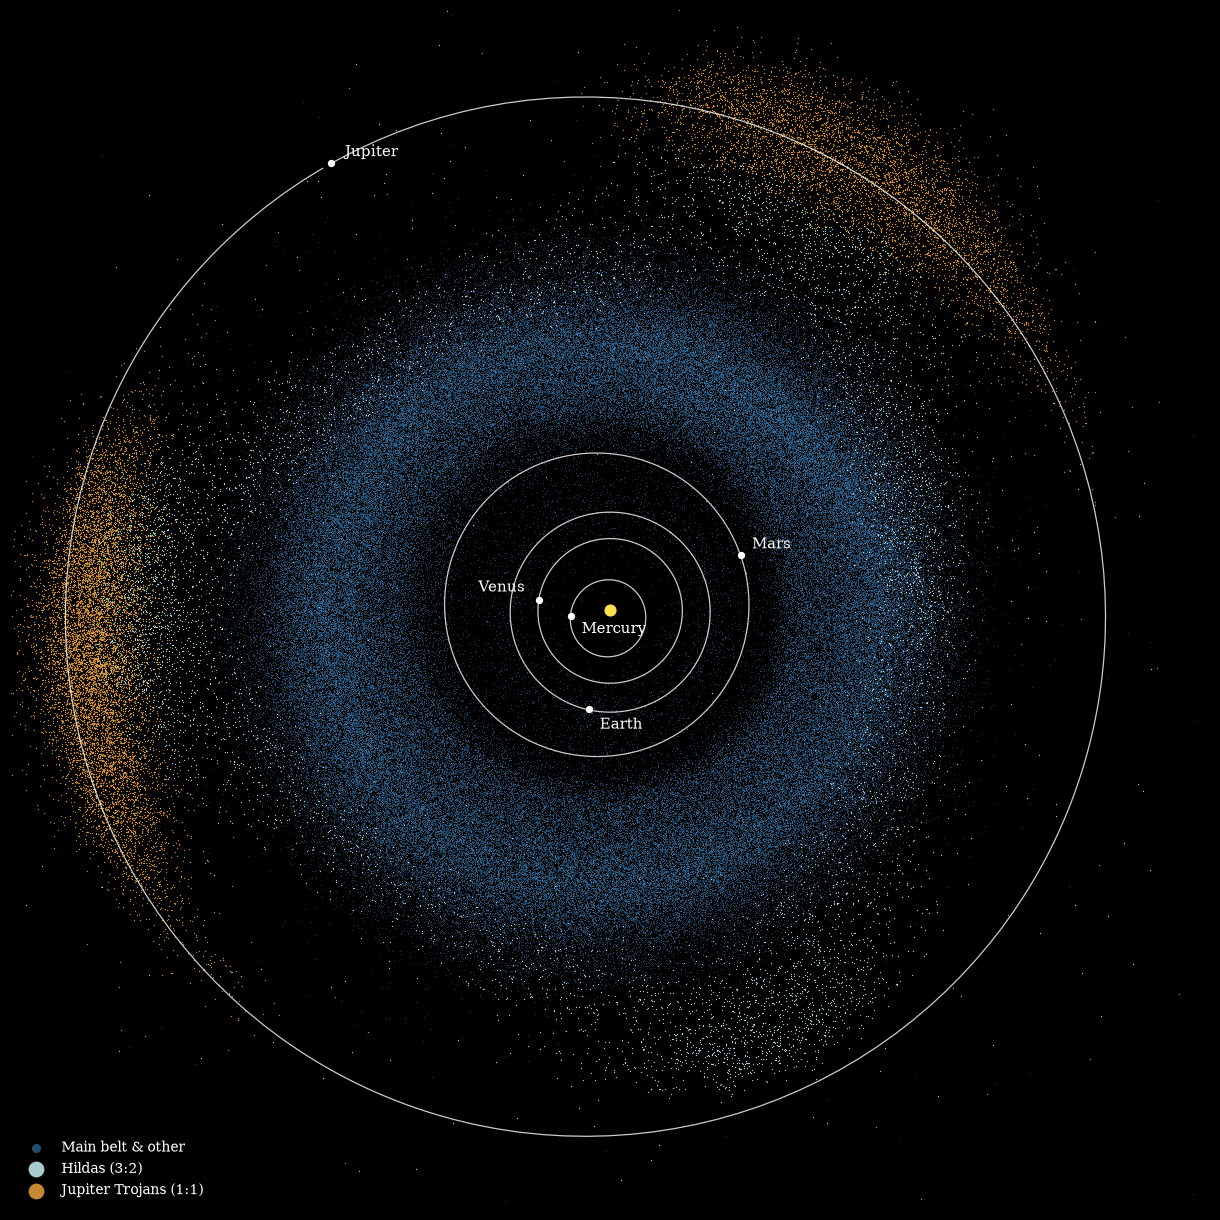

In [5]:
# Decode the packed epoch (e.g. 'K2669' -> 2026-06-09) for the planet query
def unpack_epoch(packed):
    century = {"I": 18, "J": 19, "K": 20}[packed[0]]
    year = century * 100 + int(packed[1:3])
    month = int(packed[3], 36) if packed[3].isdigit() else ord(packed[3]) - 55
    day = int(packed[4], 36) if packed[4].isdigit() else ord(packed[4]) - 55
    return year, month, day

yr, mon, day = unpack_epoch(epoch_mode)
print(f"Catalogue epoch: {yr:04d}-{mon:02d}-{day:02d}")

# Sun + planets out to Jupiter at that epoch
sim_belt = rebound.Simulation()
sim_belt.units = ("AU", "day", "Msun")
for body in ["Sun", "Mercury", "Venus", "Earth", "Mars", "Jupiter"]:
    sim_belt.add(body, date=f"{yr:04d}-{mon:02d}-{day:02d} 00:00")
sun_belt = sim_belt.particles[0]

fig, ax = plt.subplots(figsize=(12, 12), dpi=100)
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

# One dot per asteroid, coloured by population
is_hilda = (a_plot >= 3.7) & (a_plot <= 4.2)
is_trojan = (a_plot >= 5.0) & (a_plot <= 5.4)
is_belt = ~(is_hilda | is_trojan)
ax.scatter(x_plot[is_belt], y_plot[is_belt], s=0.3, color="#3f89c4",
           alpha=0.55, lw=0, zorder=2, label="Main belt & other")
ax.scatter(x_plot[is_hilda], y_plot[is_hilda], s=0.9, color="#c9f0f4",
           alpha=0.85, lw=0, zorder=3, label="Hildas (3:2)")
ax.scatter(x_plot[is_trojan], y_plot[is_trojan], s=0.9, color="#e8a23c",
           alpha=0.85, lw=0, zorder=3, label="Jupiter Trojans (1:1)")
ax.legend(loc="lower left", fontsize=10, framealpha=0, markerscale=12,
          labelcolor="white", prop={"family": "serif"})

# Planet orbits, positions, and labels
label_offsets = {"Mercury": (8, -12), "Venus": (-10, 6), "Earth": (8, -14),
                 "Mars": (8, 5), "Jupiter": (10, 5)}
for i, name in enumerate(["Mercury", "Venus", "Earth", "Mars", "Jupiter"], start=1):
    p = sim_belt.particles[i]
    pts = np.array(p.sample_orbit(Npts=300, primary=sun_belt))
    ax.plot(pts[:, 0], pts[:, 1], color="white", lw=0.9, alpha=0.8, zorder=4)
    ax.scatter([p.x - sun_belt.x], [p.y - sun_belt.y], s=18, color="white", zorder=5)
    ax.annotate(name, (p.x - sun_belt.x, p.y - sun_belt.y),
                textcoords="offset points", xytext=label_offsets[name],
                ha="right" if name == "Venus" else "left",
                fontsize=11, color="white", family="serif", zorder=6)

ax.scatter([0], [0], s=60, color="#ffe14d", zorder=5)   # the Sun
ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)
ax.set_aspect("equal")
ax.axis("off")
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()


### Reading the figure

The snapshot shows the dense blue ring of the **main belt** between roughly 2.1 and 3.3 AU, the pale triangle of the **Hildas**, and the two orange clouds of the **Jupiter Trojans** at the L4 and L5 points.

But the Kirkwood gaps are **nowhere to be seen.** There are no depleted rings carved into the belt; the annulus looks smooth all the way across. Kirkwood found the gaps in 1866 with fewer than 100 asteroids to work with; here we are looking at 200,000 positions drawn from a catalogue of 1.5 million and still cannot see them. We need to plot different variables...

# Step 4: The Histogram View — the Gaps Appear

Kirkwood's insight was to look not at *positions* but at **semi-major axes**. A mean-motion resonance is a condition on the orbital *period*: an asteroid in the 3:1 resonance completes exactly three orbits for each orbit of Jupiter. Kepler's third law ties period to semi-major axis, so each resonance picks out one specific value of a: an asteroid completing `ratio` orbits per Jupiter orbit sits at

```
a_res = a_jup * ratio**(-2/3)
```

We take Jupiter's semi-major axis directly from the Step 3 simulation (Jupiter was the last planet added, and `particle.orbit()` converts its state vector to elements), mark the classic resonances, and histogram the semi-major axes of the **full** population.

Jupiter: a = 5.2025 AU


4:1 resonance: a = 2.065 AU
3:1 resonance: a = 2.501 AU
5:2 resonance: a = 2.824 AU
7:3 resonance: a = 2.957 AU
2:1 resonance: a = 3.277 AU


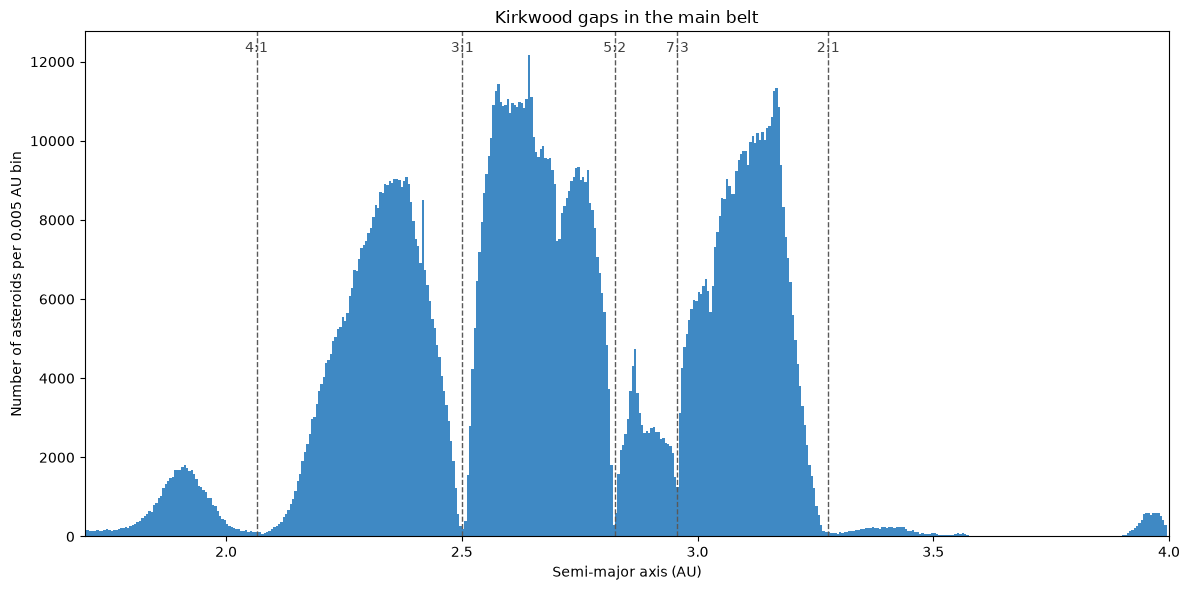

In [6]:
# Jupiter's semi-major axis, from the Step 3 simulation
a_jup = sim_belt.particles[5].orbit(primary=sun_belt).a
print(f"Jupiter: a = {a_jup:.4f} AU")

# Interior mean-motion resonances: `ratio` asteroid orbits per Jupiter orbit
resonances = {"4:1": 4, "3:1": 3, "5:2": 2.5, "7:3": 7 / 3, "2:1": 2}

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(el[:, 0], bins=np.arange(1.7, 4.0, 0.005), color="#3f89c4", lw=0)

for label, ratio in resonances.items():
    a_res = a_jup * ratio ** (-2 / 3)          # Kepler's third law
    ax.axvline(a_res, color="0.35", ls="--", lw=1)
    ax.annotate(label, (a_res, 0.98 * ax.get_ylim()[1]),
                ha="center", va="top", fontsize=10, color="0.25")
    print(f"{label} resonance: a = {a_res:.3f} AU")

ax.set_xlim(1.7, 4.0)
ax.set_xlabel("Semi-major axis (AU)")
ax.set_ylabel("Number of asteroids per 0.005 AU bin")
ax.set_title("Kirkwood gaps in the main belt")
fig.tight_layout()
plt.show()

### Reading the figure

The gaps are unmistakable — and they sit exactly on the dashed resonance lines:

- The **3:1, 5:2, 7:3, and 2:1** resonances each carve a sharp, deep gap out of the distribution. These are the classic Kirkwood gaps.
- The **4:1** resonance marks the *inner edge* of the belt. Interior to it, the small isolated spike near 1.9 AU is the **Hungaria** group.
- Beyond the **2:1** the belt essentially ends. The region is nearly empty apart from the **Cybele** group (roughly 3.4–3.5 AU) and, at the very right edge of the frame near 3.97 AU, the rising edge of the **Hildas** — a population that *survives* by living **in** the 3:2 resonance, protected by it rather than cleared by it. Whether a resonance empties or shelters depends on its detailed dynamics.

Why are the gaps empty? For over a century after Kirkwood the mechanism was unclear: the resonance locations were obvious, but not how a resonance actually removes bodies. The modern answer was established for the 3:1 gap by [Wisdom (1983)](https://ui.adsabs.harvard.edu/abs/1983Icar...56...51W): motion inside the resonance is **chaotic**, and the chaos drives large, intermittent jumps in eccentricity. A resonant asteroid is eventually pumped onto a planet-crossing orbit and removed by a close encounter or a collision. The gaps are not places asteroids avoid — they are places asteroids do not survive.

# Step 5: Why the Map Hides the Gaps

The resolution of the paradox is **eccentricity**. The gaps are carved in semi-major axis, but the map shows each asteroid's instantaneous **heliocentric distance** — and over one orbit an asteroid with elements (a, e) sweeps its distance across the whole range from a(1 − e) at perihelion to a(1 + e) at aphelion. Typical main-belt eccentricities are about 0.15, so an asteroid with a = 2.5 AU ranges between roughly 2.1 and 2.9 AU — smearing a gap a few hundredths of an AU wide over more than half an AU. At any instant, objects from either side of a gap are passing *through* it in distance.

The two panels below make the point with the same full population and identical bins: the distribution of semi-major axis `a` (top) against the distribution of the instantaneous distance `r` from Step 2 (bottom).

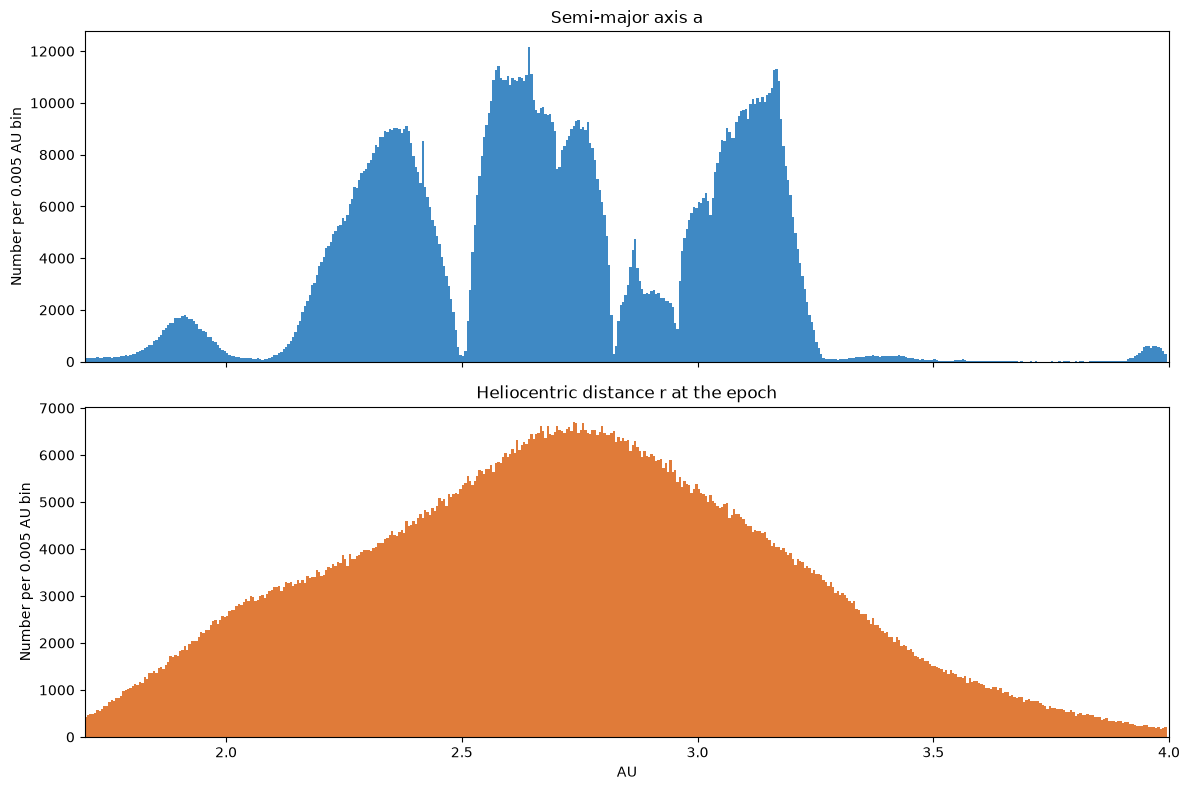

In [7]:
bins = np.arange(1.7, 4.0, 0.005)

fig, (ax_a, ax_r) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax_a.hist(el[:, 0], bins=bins, color="#3f89c4", lw=0)
ax_a.set_title("Semi-major axis a")
ax_a.set_ylabel("Number per 0.005 AU bin")

ax_r.hist(r, bins=bins, color="#e07b39", lw=0)
ax_r.set_title("Heliocentric distance r at the epoch")
ax_r.set_ylabel("Number per 0.005 AU bin")
ax_r.set_xlabel("AU")

ax_r.set_xlim(1.7, 4.0)
fig.tight_layout()
plt.show()

The contrast is total: every gap in the top panel vanishes in the bottom one — even the deep 3:1 gap leaves no trace in the distribution of distance, which is a single smooth hump. The (x, y) snapshot of Step 3 is a picture of `r`, not of `a`, which is why the belt looked seamless there.

This is also why Kirkwood could make the discovery at all: the gaps live in the *orbits*, not in the positions, and orbital elements are exactly what orbit determination extracts from the observations.

# Step 6: A Map That Shows the Gaps — the Normalized Belt

Understanding why the map fails tells us how to fix it. If eccentricity is what smears the gaps away, then simply *remove* it: keep each asteroid's current heliocentric longitude λ (from its Step 2 position), but plot it at a radius equal to its **semi-major axis** instead of its instantaneous distance:

```
lam = arctan2(y, x)
x_n = a * cos(lam)
y_n = a * sin(lam)
```

This circularizes every orbit — each asteroid is shown where it is *around* the Sun, but at the radius of its mean orbit, "ignoring e and i". A beautiful example of this construction appears on the Wikipedia Kirkwood-gap page as [*The Asteroid Belt (ignoring e and i)*](https://en.wikipedia.org/wiki/Kirkwood_gap#/media/File:Asteroid_belt_normalized_2026-05-15.png); here we build the same view from our MPCORB data, keeping the colour scheme of the Step 3 map. Because the gaps are only a few hundredths of an AU wide, this figure plots the **full** population — every dot of density helps the dark rings stand out.


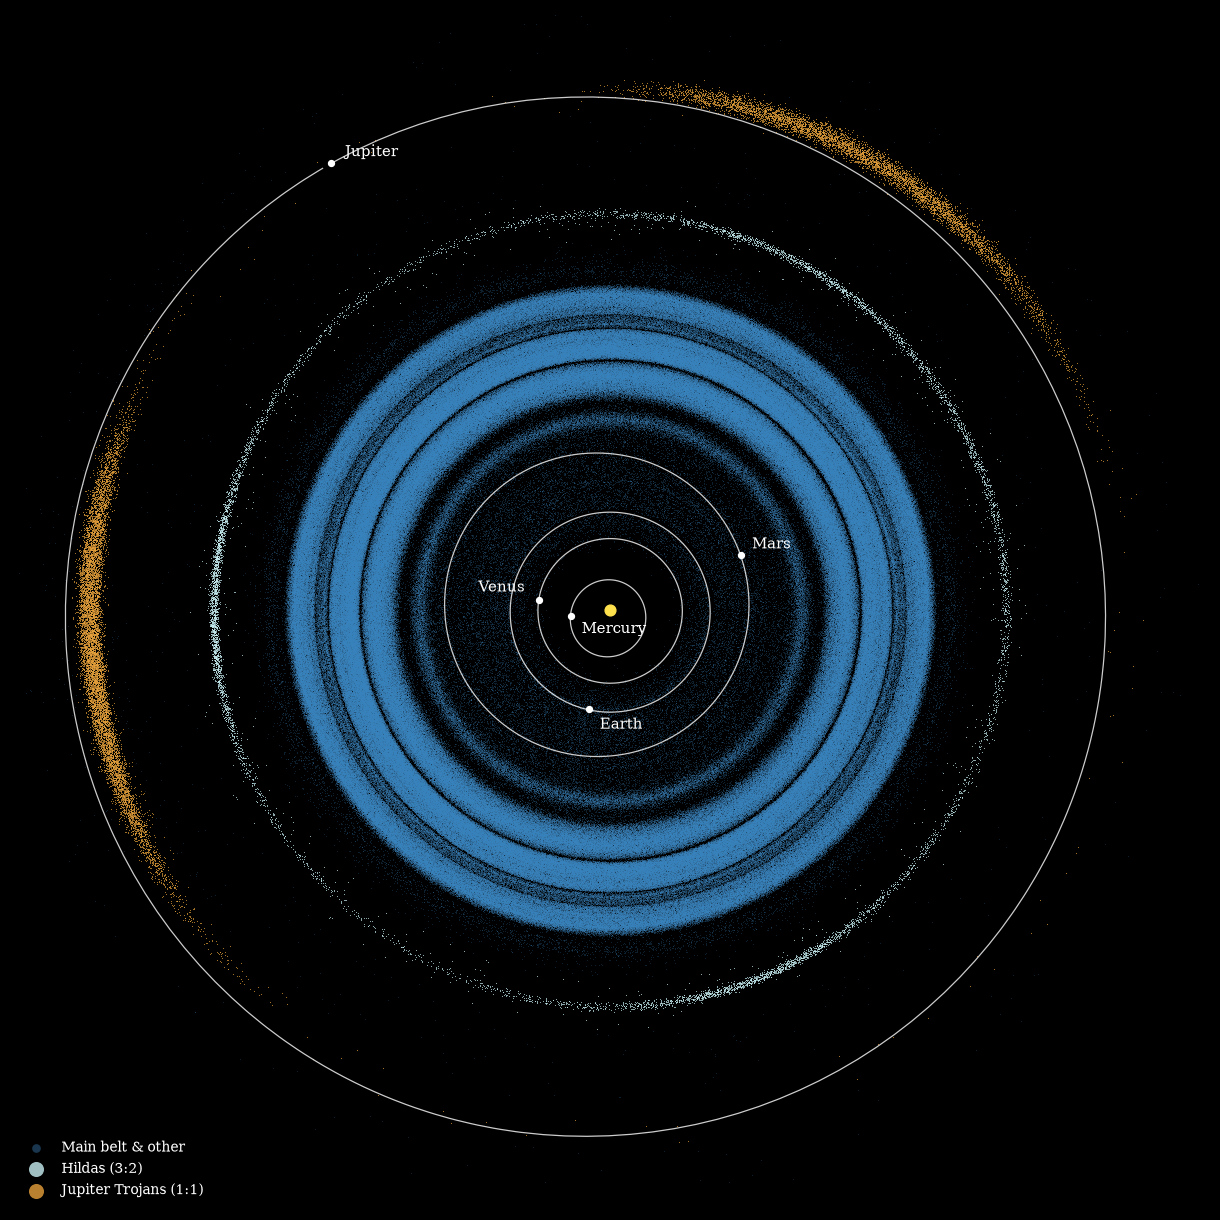

In [8]:
# Normalize: radius = semi-major axis, angle = current heliocentric longitude
lam = np.arctan2(y, x)
x_n = a * np.cos(lam)
y_n = a * np.sin(lam)

fig, ax = plt.subplots(figsize=(12, 12), dpi=100)
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

# One dot per asteroid -- the FULL population, coloured as in Step 3
is_hilda_full = (a >= 3.7) & (a <= 4.2)
is_trojan_full = (a >= 5.0) & (a <= 5.4)
is_belt_full = ~(is_hilda_full | is_trojan_full)
ax.scatter(x_n[is_belt_full], y_n[is_belt_full], s=0.2, color="#3f89c4",
           alpha=0.4, lw=0, zorder=2, label="Main belt & other")
ax.scatter(x_n[is_hilda_full], y_n[is_hilda_full], s=0.6, color="#c9f0f4",
           alpha=0.8, lw=0, zorder=3, label="Hildas (3:2)")
ax.scatter(x_n[is_trojan_full], y_n[is_trojan_full], s=0.6, color="#e8a23c",
           alpha=0.8, lw=0, zorder=3, label="Jupiter Trojans (1:1)")
ax.legend(loc="lower left", fontsize=10, framealpha=0, markerscale=14,
          labelcolor="white", prop={"family": "serif"})

# Planet orbits, positions, and labels (reusing the Step 3 simulation)
for i, name in enumerate(["Mercury", "Venus", "Earth", "Mars", "Jupiter"], start=1):
    p = sim_belt.particles[i]
    pts = np.array(p.sample_orbit(Npts=300, primary=sun_belt))
    ax.plot(pts[:, 0], pts[:, 1], color="white", lw=0.9, alpha=0.8, zorder=4)
    ax.scatter([p.x - sun_belt.x], [p.y - sun_belt.y], s=18, color="white", zorder=5)
    ax.annotate(name, (p.x - sun_belt.x, p.y - sun_belt.y),
                textcoords="offset points", xytext=label_offsets[name],
                ha="right" if name == "Venus" else "left",
                fontsize=11, color="white", family="serif", zorder=6)

ax.scatter([0], [0], s=60, color="#ffe14d", zorder=5)   # the Sun
ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)
ax.set_aspect("equal")
ax.axis("off")
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()


### Reading the figure

Now the map and the histogram finally agree. With every orbit circularized, the Kirkwood gaps appear as **dark rings** carved into the belt — the 3:1 gap is the prominent ring near 2.5 AU, with the 5:2, 7:3, and 2:1 gaps beyond it — and the belt acquires the crisp inner and outer edges (at the 4:1 and 2:1 resonances) that the histogram showed. The **Hildas** collapse from a smeared triangle into a thin ring at 3.97 AU whose density still varies around the circumference — three denser arcs, the ghost of the triangle. The **Trojans** hug Jupiter's orbit in two arcs centred on the L4 and L5 points.

Compare this figure directly with Step 3: same asteroids, same instant, same colours — the only change is that each dot's distance from the Sun is drawn as `a` instead of `r`. Structure in the orbits becomes structure you can see.

# Summary

In this tutorial we:

1. **Downloaded and parsed** the full [`MPCORB.DAT`](https://minorplanetcenter.net/iau/MPCORB.html) catalogue — roughly 1.5 million orbits — reusing the streaming fixed-width pipeline from the companion plotting tutorial
2. **Computed** heliocentric positions for the entire population at the common catalogue epoch with a vectorized Kepler solver
3. **Mapped** the belt as an (x, y) snapshot, coloured by population — and found no trace of the Kirkwood gaps
4. **Histogrammed** the semi-major axes — and found the gaps razor-sharp, each aligned with a Jupiter mean-motion resonance located via Kepler's third law, with the depletion mechanism traced to resonant chaos ([Wisdom 1983](https://ui.adsabs.harvard.edu/abs/1983Icar...56...51W))
5. **Resolved** the paradox: eccentricity smears semi-major-axis structure over more than half an AU of heliocentric distance, so a snapshot of positions — a picture of r, not a — cannot show the gaps
6. **Redrew the map with every orbit circularized** (radius = a, angle = current longitude, "ignoring e and i"), making the gaps visible as dark rings, the Hildas a thin ring, and the Trojans two arcs on Jupiter's orbit

### Further Resources

- [Kirkwood gap (Wikipedia)](https://en.wikipedia.org/wiki/Kirkwood_gap), including the normalized-belt figure [*The Asteroid Belt (ignoring e and i)*](https://en.wikipedia.org/wiki/Kirkwood_gap#/media/File:Asteroid_belt_normalized_2026-05-15.png) that inspired Step 6
- [Wisdom (1983), *Chaotic behavior and the origin of the 3/1 Kirkwood gap*, Icarus 56, 51](https://ui.adsabs.harvard.edu/abs/1983Icar...56...51W)
- [MPCORB page](https://minorplanetcenter.net/iau/MPCORB.html) and the [MPC data page (bulk orbit files)](https://minorplanetcenter.net/data)
- [Minor Planet Orbit Format documentation](https://docs.minorplanetcenter.net/mpc-ops-docs/orbits/minor-planet-orbit-format/)
- [Packed dates documentation](https://docs.minorplanetcenter.net/mpc-ops-docs/designations/packed-dates/)
- [Companion tutorial: Plotting Asteroid Orbits](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_plotting/)
- [Companion tutorial: From MPC Orbit to N-Body Simulation](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_to_rebound/)

For questions or feedback, contact the MPC via the [Jira Helpdesk](https://mpc-service.atlassian.net/servicedesk/customer/portal/13/create/148).